# 02 – Análisis exploratorio (EDA) y visualizaciones

En este cuaderno vamos a explorar el dataset **limpio** de videojuegos de Steam:

- Entender la distribución de precios, puntuaciones y popularidad.
- Analizar los géneros y etiquetas más frecuentes.
- Ver la relación entre calidad percibida y popularidad.
- Generar tablas y gráficos que luego podremos reutilizar en dashboards
  (por ejemplo, en la app de Streamlit).

Trabajaremos a partir del archivo:

`data/processed/games_clean.parquet`

que se genera en el notebook **01_data_overview_and_cleaning** o desde
el módulo `src/data/clean_data.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

def get_project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if (parent / "data").exists() and (parent / "requirements.txt").exists():
            return parent
    return p.parents[0]

PROJECT_ROOT = get_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
path = PROCESSED_DIR / "df_clean.parquet"

df = pd.read_parquet(path)
print("Shape:", df.shape)
display(df.head(3))

Shape: (122611, 38)


,app_id,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,windows,mac,linux,metacritic_score,achievements,recommendations,supported_languages,full_audio_languages,developers,publishers,categories,genres,screenshots,user_score,positive,negative,estimated_owners,average_playtime_forever,discount,peak_ccu,tags,text_description,has_text,release_date_raw,release_year,tags_text
0,2539430,Black Dragon Mage Playtest,2023-08-01,0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,,True,False,False,0,0,0,[],[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,0,0,0,0 - 0,0,0,0,[],NaN,False,"Aug 1, 2023",2023,
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,True,False,False,0,0,231,[English],[],[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[https://shared.akamai.steamstatic.com/store_i...,0,252,3,0 - 20000,8,65,0,"[adventure, visual novel, anime, cute]","Springtime, April: when the cherry trees come ...",True,"Jul 29, 2016",2016,adventure; visual novel; anime; cute
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,True,True,False,0,0,0,"[English, French, German, Russian]",[],[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[https://shared.akamai.steamstatic.com/store_i...,0,21,3,0 - 20000,0,0,0,"[casual, card game, solitaire, puzzle, hidden ...","Immerse yourself in the most beloved, mystical...",True,"May 6, 2019",2019,casual; card game; solitaire; puzzle; hidden o...


### Creamos una copia (`df_eda`) y generamos variables derivadas que son más útiles para análisis y modelado:

- `reviews_total`: total de reseñas (positivas + negativas).
- `rating_ratio`: proporción de reseñas positivas sobre el total (0 a 1).
- `rating_pct`: el mismo ratio en porcentaje (0 a 100).
- Variables `log1p_*` para colas largas: `log1p_price`, `log1p_reviews_total`, `log1p_recommendations`, etc.

### Por qué importa en el recomendador
Estas variables ayudan a representar:
- **Popularidad**: `recommendations`, `reviews_total`
- **Calidad percibida por usuarios**: `rating_pct`, `user_score`
- **Engagement**: `average_playtime_forever`
- **Accesibilidad**: `price`, plataformas, idiomas

In [2]:
df_eda = df.copy()

col_pos = next((c for c in ["positive", "pos_reviews", "recommendations_up"] if c in df_eda.columns), None)
col_neg = next((c for c in ["negative", "neg_reviews", "recommendations_down"] if c in df_eda.columns), None)
col_price = next((c for c in ["price", "price_usd", "final_price"] if c in df_eda.columns), None)

if col_pos and col_neg:
    df_eda["reviews_total"] = (df_eda[col_pos].fillna(0) + df_eda[col_neg].fillna(0)).astype(float)
    df_eda["rating_ratio"] = (df_eda[col_pos].fillna(0) / df_eda["reviews_total"].replace(0, np.nan)).clip(0, 1)
    df_eda["rating_pct"] = (df_eda["rating_ratio"] * 100).round(2)

# logs para colas largas (solo si existe la columna)
for c in [col_price, col_pos, col_neg, "reviews_total", "recommendations", "average_playtime_forever"]:
    if c and c in df_eda.columns:
        df_eda[f"log1p_{c}"] = np.log1p(pd.to_numeric(df_eda[c], errors="coerce"))

print("df_eda shape:", df_eda.shape)
display(df_eda.head(3))

df_eda shape: (122611, 47)


,app_id,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,windows,mac,linux,metacritic_score,achievements,recommendations,supported_languages,full_audio_languages,developers,publishers,categories,genres,screenshots,user_score,positive,negative,estimated_owners,average_playtime_forever,discount,peak_ccu,tags,text_description,has_text,release_date_raw,release_year,tags_text,reviews_total,rating_ratio,rating_pct,log1p_price,log1p_positive,log1p_negative,log1p_reviews_total,log1p_recommendations,log1p_average_playtime_forever
0,2539430,Black Dragon Mage Playtest,2023-08-01,0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,,True,False,False,0,0,0,[],[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,0,0,0,0 - 0,0,0,0,[],NaN,False,"Aug 1, 2023",2023,,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,True,False,False,0,0,231,[English],[],[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[https://shared.akamai.steamstatic.com/store_i...,0,252,3,0 - 20000,8,65,0,"[adventure, visual novel, anime, cute]","Springtime, April: when the cherry trees come ...",True,"Jul 29, 2016",2016,adventure; visual novel; anime; cute,255.0,0.988235,98.82,1.830980,5.533389,1.386294,5.545177,5.446737,2.197225
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,True,True,False,0,0,0,"[English, French, German, Russian]",[],[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[https://shared.akamai.steamstatic.com/store_i...,0,21,3,0 - 20000,0,0,0,"[casual, card game, solitaire, puzzle, hidden ...","Immerse yourself in the most beloved, mystical...",True,"May 6, 2019",2019,casual; card game; solitaire; puzzle; hidden o...,24.0,0.875000,87.50,1.790091,3.091042,1.386294,3.218876,0.000000,0.000000


In [3]:
print("Shape:", df_eda.shape)

# tipos
display(df_eda.dtypes.astype(str).value_counts())

# list-like cols (ndarray)
list_cols = [c for c in df_eda.columns if df_eda[c].dropna().head(2000).apply(lambda x: isinstance(x, np.ndarray)).any()]
print("List-like cols:", list_cols)

Shape: (122611, 47)


int64             11
float64           10
str               10
object             8
bool               4
string             2
datetime64[us]     1
int32              1
Name: count, dtype: int64

List-like cols: ['supported_languages', 'full_audio_languages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'tags']


## Conociendo el dataset (shape, tipos, columnas list-like)

### Qué vemos
- `Shape`: cuántas filas (juegos) y columnas (atributos).
- `dtype counts`: qué tipo de datos predominan (numéricos, texto, listas).
- Columnas **list-like** (arrays): por ejemplo `genres`, `tags`, `categories`, `developers`, `supported_languages`.

### Relevancia
- Define cómo se puede analizar cada columna:
  - Las numéricas permiten histograms, correlaciones, regresiones.
  - Las de texto sirven para NLP/embeddings.
  - Las list-like no se analizan “directo”: se analizan explotando listas (frecuencias y co-ocurrencias).

### Conclusiones
- El dataset es lo suficientemente grande para entrenar y evaluar un recomendador basado en contenido.
- La presencia de `genres`, `tags` y descripciones habilita un recomendador semántico (Sentence Transformers / embeddings).
- La mezcla de señales de calidad (ratings) y popularidad (reviews/recommendations/playtime) habilita estrategias de ranking más inteligentes.


In [4]:
missing = (df_eda.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
display(missing.head(20).to_frame("missing_%"))

# duplicados por fila excluyendo list-like
cols_for_dups = [c for c in df_eda.columns if c not in list_cols]
print("Duplicados (fila completa, excluyendo list-like):", df_eda[cols_for_dups].duplicated().sum())

# duplicados por ID
id_col = "app_id" if "app_id" in df_eda.columns else next((c for c in ["appID","appid","steam_appid","id"] if c in df_eda.columns), None)
print("ID column:", id_col)
if id_col:
    print("Duplicados por ID:", df_eda.duplicated(subset=[id_col]).sum())

,missing_%
rating_ratio,32.347832
rating_pct,32.347832
text_description,6.772639


Duplicados (fila completa, excluyendo list-like): 0
ID column: app_id
Duplicados por ID: 0


### Qué vemos

- **Missingness**: qué columnas tienen valores faltantes y en qué proporción.
- **Duplicados**: si existen juegos repetidos por fila o por identificador (`app_id` / `appID`).

### Relevancia
- Los faltantes determinan si una variable se puede usar como feature o solo como señal auxiliar.
- Los duplicados pueden distorsionar:
  - métricas de popularidad,
  - conteos por género/tag,
  - y entrenamiento (porque “repites” juegos).

### Interpretación de resultados
- `Duplicados por ID: 0`  
  ✅ Cada juego está representado una sola vez.

- Missing:
  - `rating_pct` y `rating_ratio` ~32% **una parte importante del catálogo no tiene señal completa de reseñas (común en catálogos grandes).** 
  - `text_description` ~6.8%  **hay pocos juegos sin texto.**  

### Conclusión 
La data es consistente (sin duplicados). El hueco principal está en ratings, lo cual es normal y se gestiona usando ratings como señal opcional.

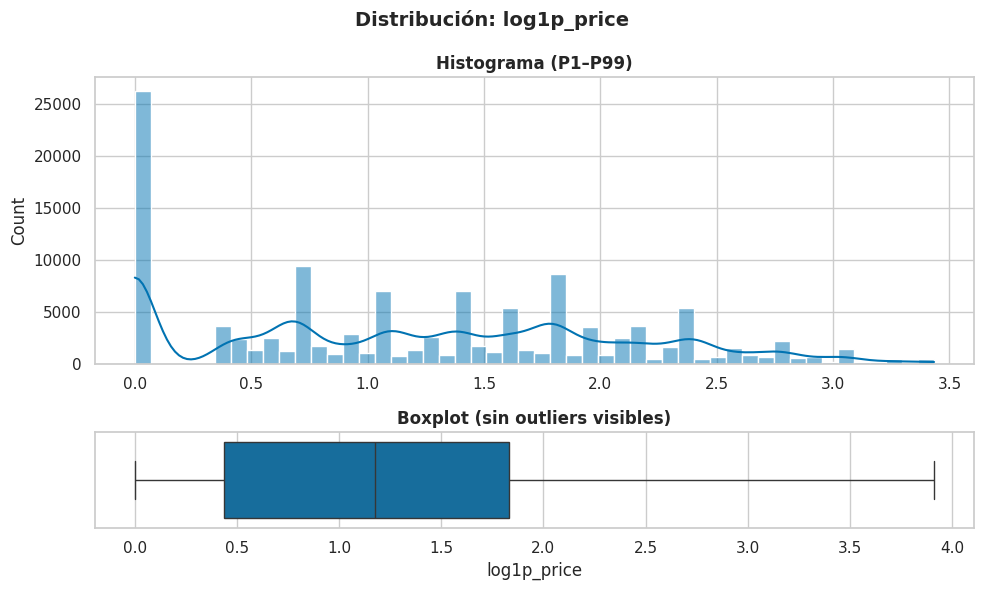

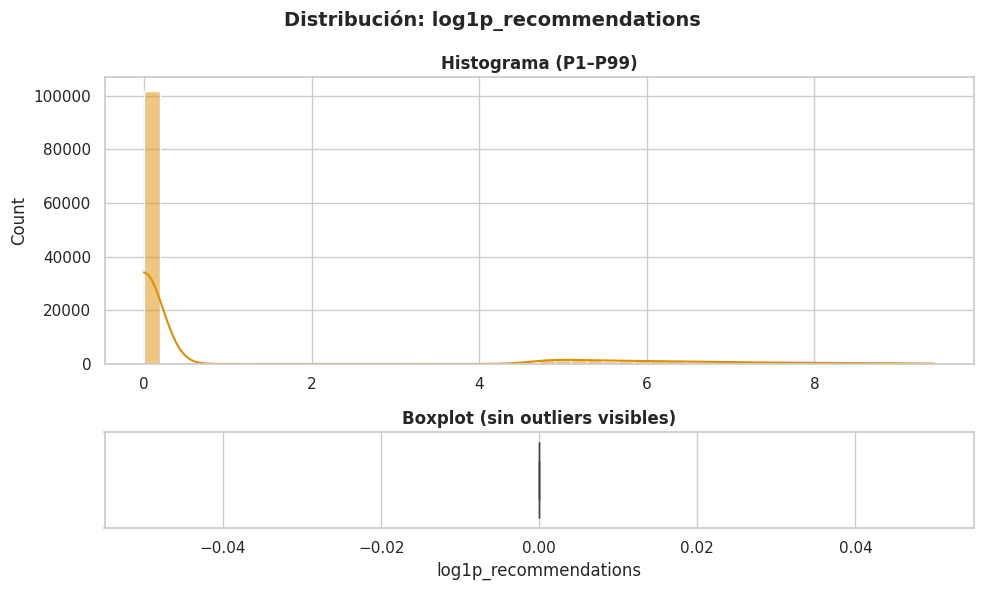

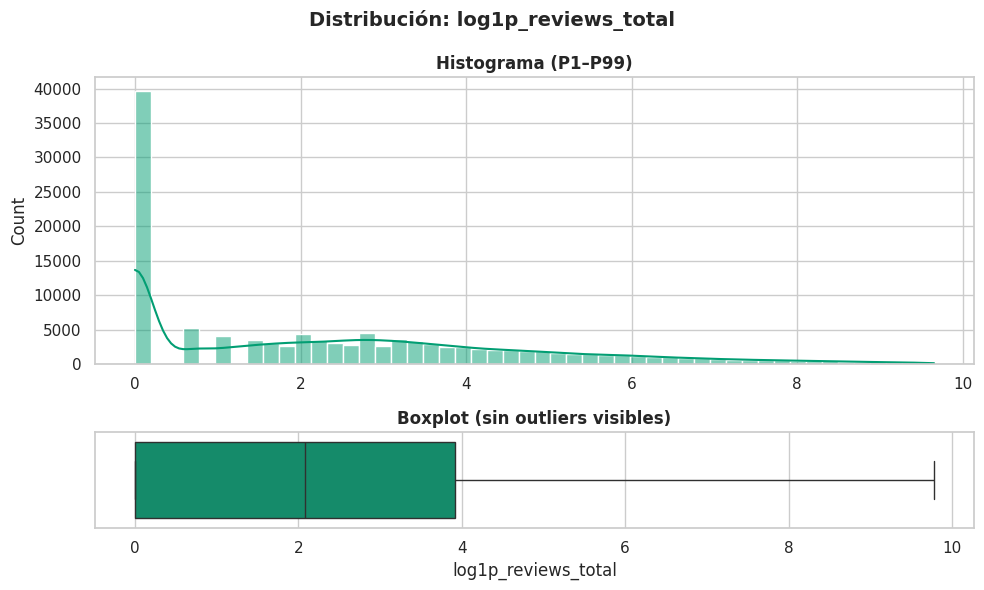

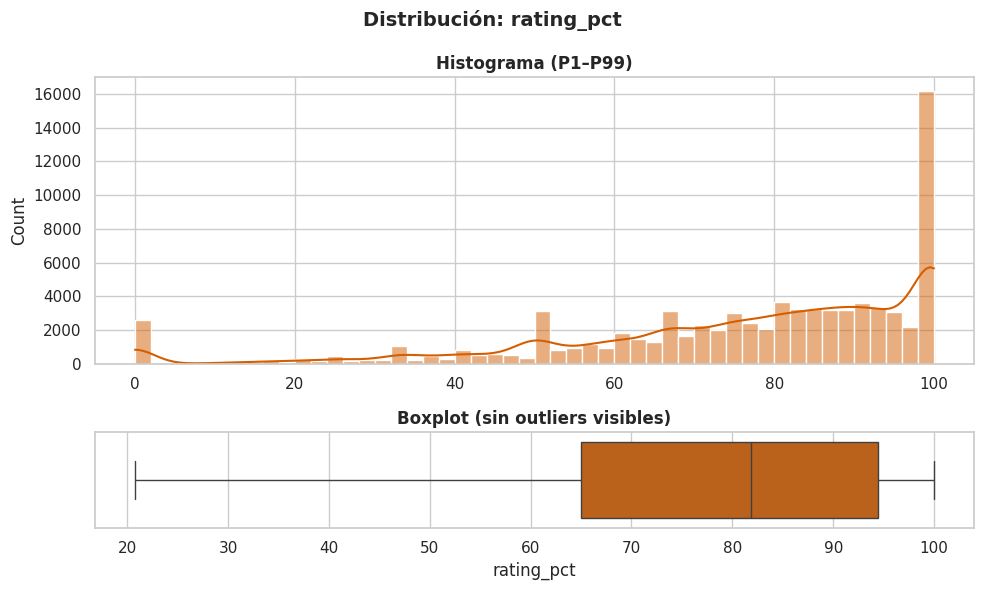

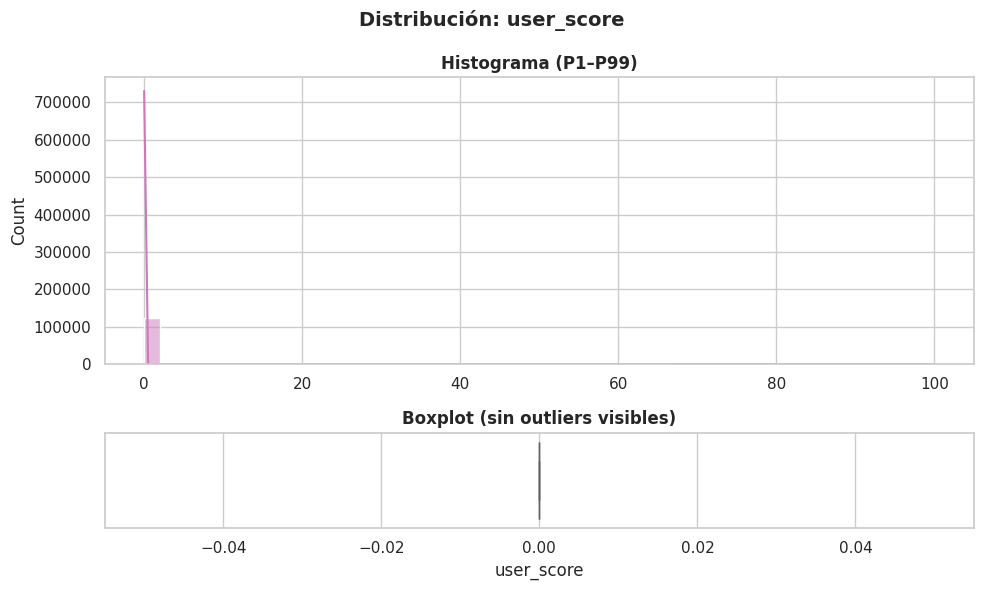

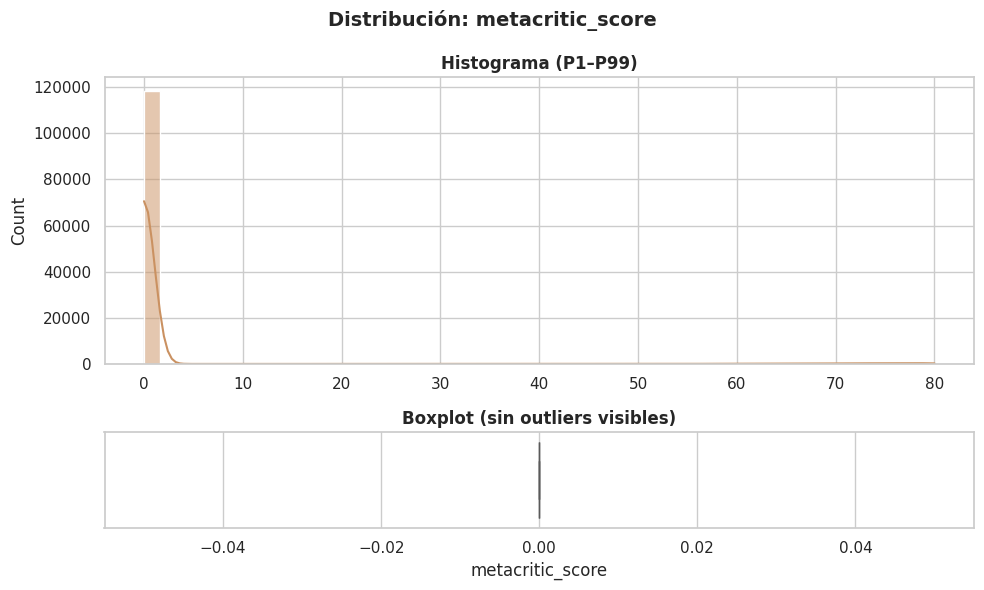

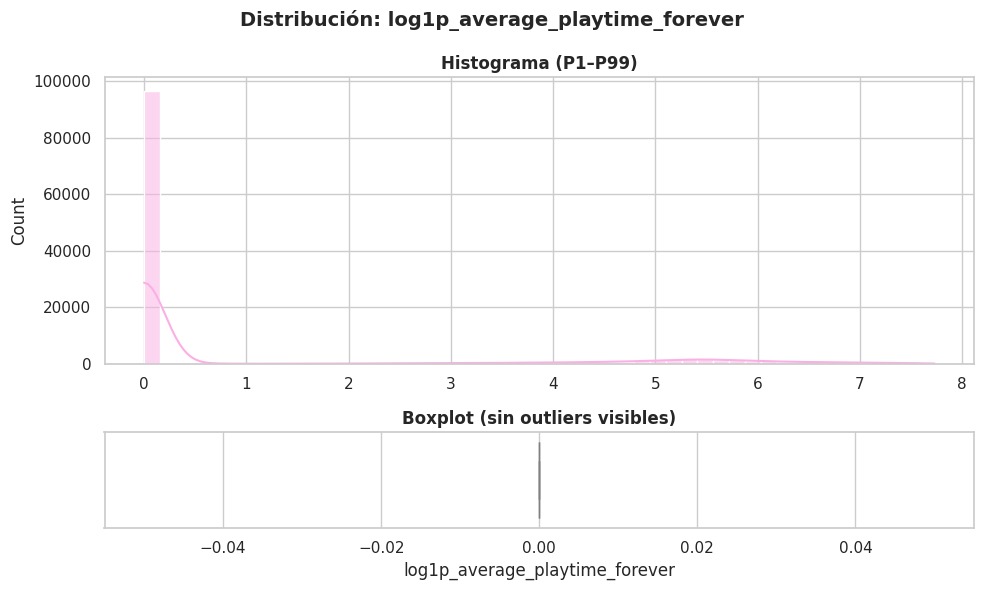

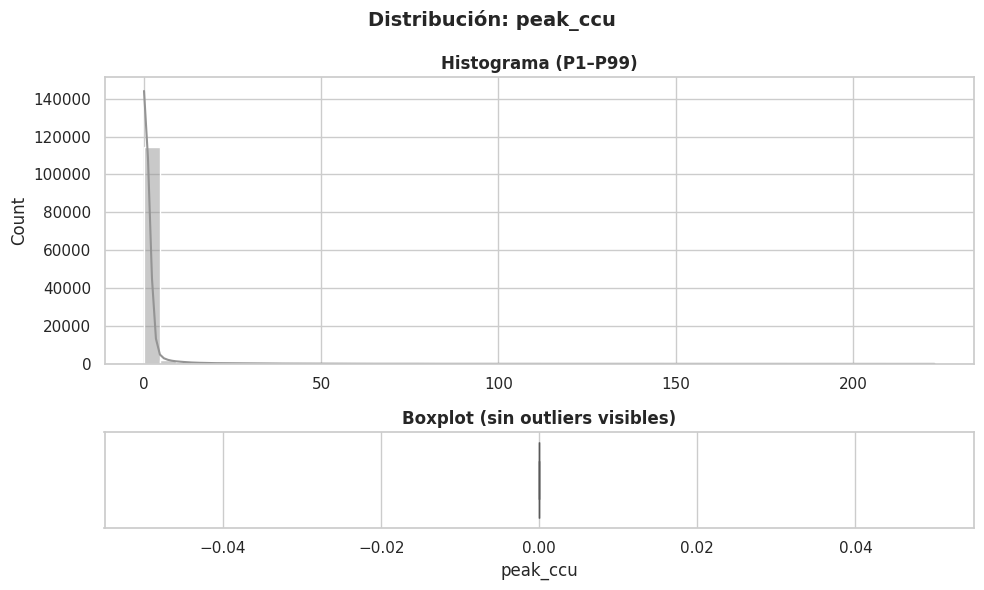

In [5]:
candidates = [
    "log1p_price", "log1p_recommendations", "log1p_reviews_total",
    "rating_pct", "user_score", "metacritic_score",
    "log1p_average_playtime_forever", "peak_ccu"
]
plot_cols = [c for c in candidates if c in df_eda.columns]

palette = sns.color_palette("colorblind", len(plot_cols))

def plot_univariate_numeric(df, col, color, q_low=0.01, q_high=0.99, bins=50):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if s.empty:
        return False
    lo, hi = s.quantile(q_low), s.quantile(q_high)
    s_clip = s[(s >= lo) & (s <= hi)] if lo < hi else s

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios":[3,1]})
    fig.suptitle(f"Distribución: {col}", fontsize=14, fontweight="bold", y=0.98)

    sns.histplot(s_clip, kde=True, bins=bins, ax=axes[0], color=color)
    axes[0].set_title(f"Histograma (P{int(q_low*100)}–P{int(q_high*100)})", fontweight="bold")
    axes[0].set_xlabel("")

    sns.boxplot(x=s, ax=axes[1], color=color, showfliers=False)
    axes[1].set_title("Boxplot (sin outliers visibles)", fontweight="bold")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()
    return True

for i, col in enumerate(plot_cols):
    plot_univariate_numeric(df_eda, col, color=palette[i])

### Qué analizamos
Distribución de variables numéricas clave:  
- precio (y free-to-play),
- popularidad (`recommendations`, `reviews_total`),
- engagement (`average_playtime_forever`),
- calidad (`rating_pct`, `user_score`, `metacritic_score`).

Se grafican con:
- Histograma + KDE (forma general)
- Boxplot (concentración, asimetría, outliers)

### Relevancia
En Steam, la mayoría de estas variables presentan **colas largas**:
- pocos juegos concentran la mayoría de recomendaciones/reseñas/horas jugadas,
- muchos juegos tienen valores muy bajos o 0.

Esto afecta:
- visualización (si no se transforma, no se ve nada),
- y modelado (si se mezclan señales numéricas, los outliers dominan).

### Conclusión
- Popularidad y playtime tienen cola larga fuerte → se justifican transformaciones `log1p`.
- Precio presenta masa en valores bajos y posible `price=0` → justifica feature “free_to_play” o filtros de presupuesto.
- Metacritic/user_score suelen tener missing o valores 0 → se usan como señales auxiliares, no como “columna obligatoria”.

---

## Transformaciones `log1p` para colas largas

### Por qué se usa
- Mantiene el 0 (no rompe juegos free o sin recomendaciones).
- Reduce el efecto de valores extremos (outliers).
- Hace visibles los patrones donde está la mayoría de juegos.

### Interpretación (sin matemáticas)
La escala log permite comparar mejor juegos “normales” sin que unos pocos hiper populares aplasten la lectura.

### Evidencia con el precio en este dataset
Según el resumen:
- mediana ≈ $2.24
- 75% ≤ $5.24
- máximo ≈ $999.98

**hay outliers fuertes que distorsionan la escala normal.**

**`log1p_price` hace legible la distribución real del mercado.**

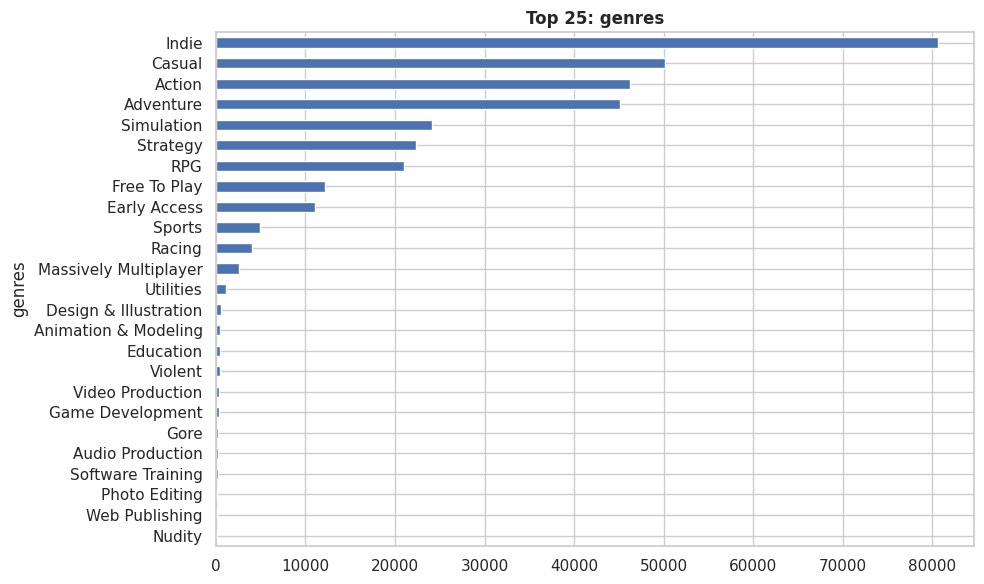

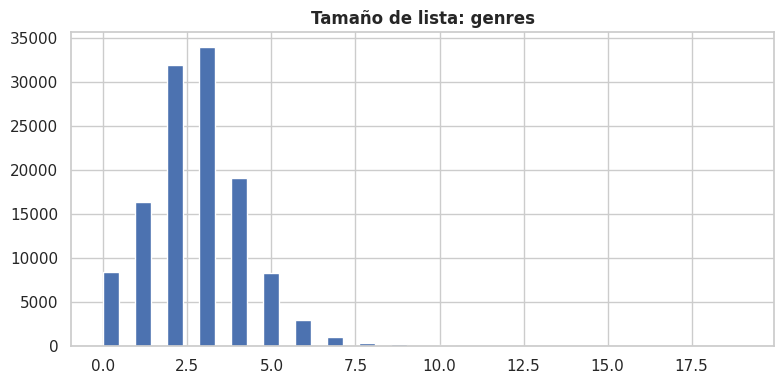

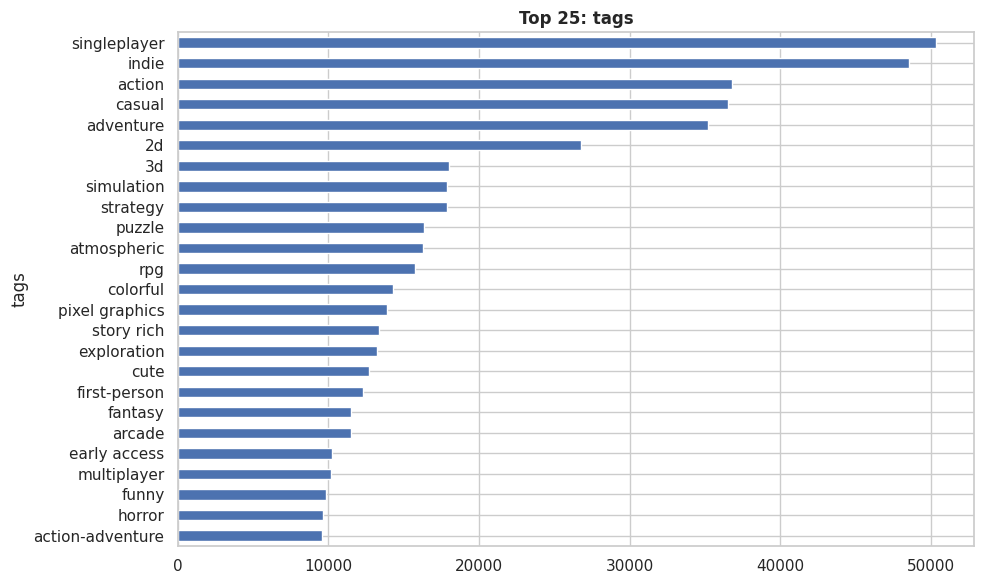

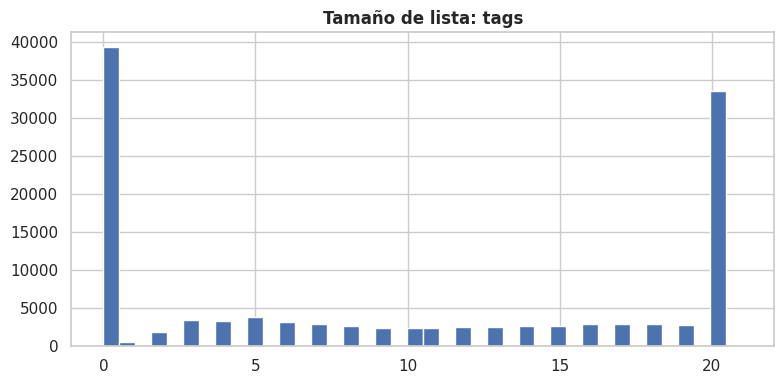

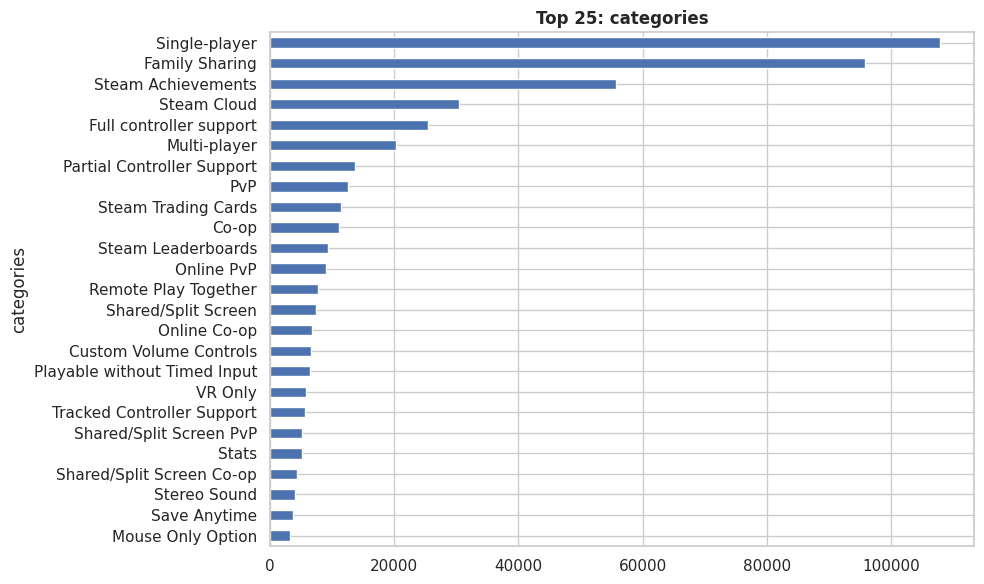

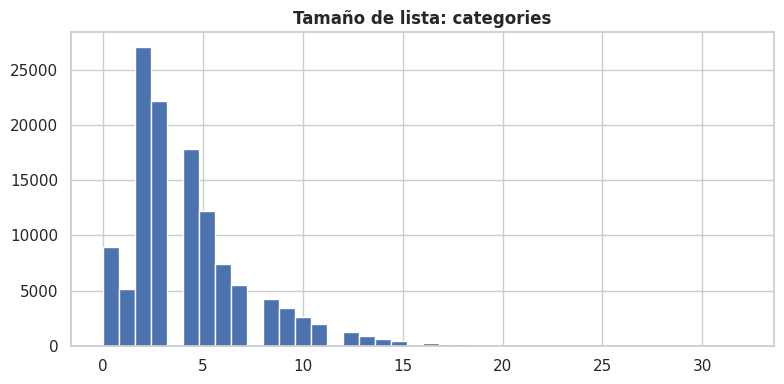

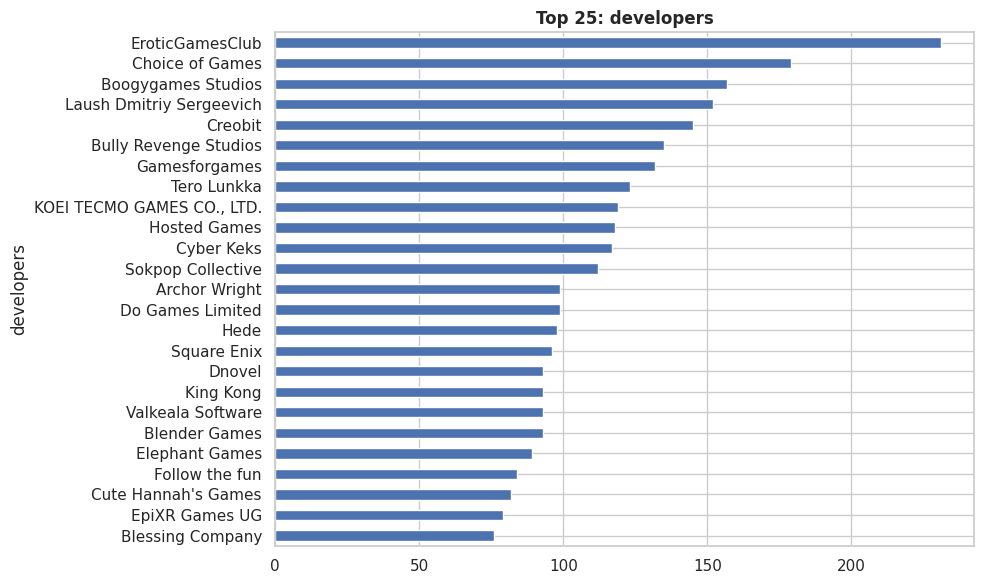

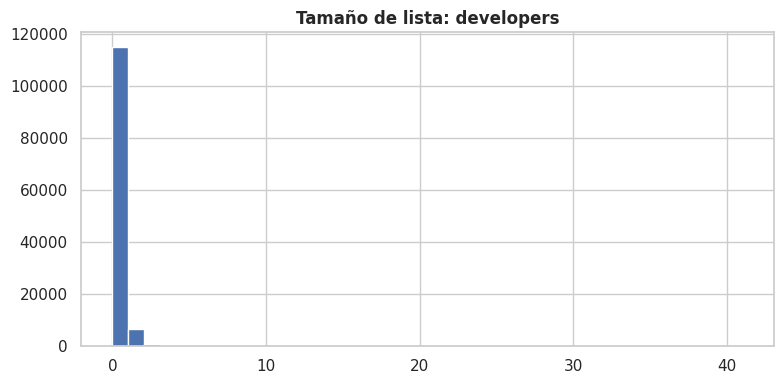

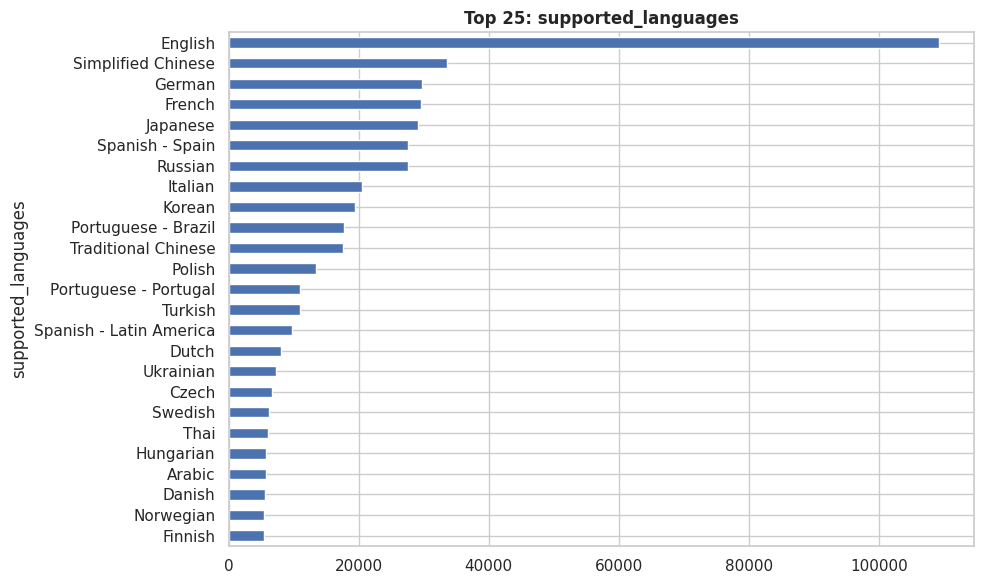

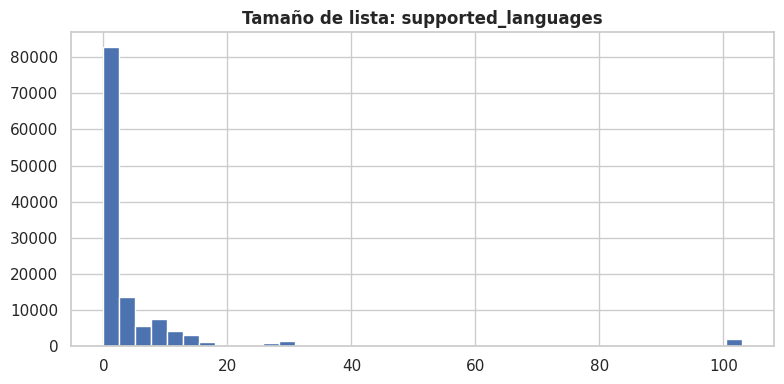

In [6]:
def explode_counts(df, col, top_k=25):
    s = df[col].dropna().apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
    ex = pd.Series(s).explode().dropna().astype(str).str.strip()
    ex = ex[(ex != "") & (ex.str.lower() != "nan")]

    vc = ex.value_counts().head(top_k).sort_values()
    plt.figure(figsize=(10,6))
    vc.plot(kind="barh")
    plt.title(f"Top {top_k}: {col}", fontweight="bold")
    plt.tight_layout()
    plt.show()

def list_size(x):
    if isinstance(x, np.ndarray):
        return len(x)
    if isinstance(x, list):
        return len(x)
    return np.nan

for c in ["genres", "tags", "categories", "developers", "supported_languages"]:
    if c in df_eda.columns:
        explode_counts(df_eda, c, top_k=25)

        sizes = df_eda[c].apply(list_size).dropna()
        plt.figure(figsize=(8,4))
        plt.hist(sizes, bins=40)
        plt.title(f"Tamaño de lista: {c}", fontweight="bold")
        plt.tight_layout()
        plt.show()

Prueba

## Univariante list-like (genres/tags/categories/developers/languages)

### Qué analizamos
- **Frecuencias Top 25**: los géneros/tags/categorías más comunes.
- **Tamaño de lista por juego**: cuántos tags o géneros trae cada título.

### Relevancia
- `genres` y `tags` suelen ser la base de recomendación por contenido (y un buen respaldo de interpretabilidad).
- La cantidad de tags por juego determina la riqueza del contenido:
  - pocos tags → menos señal semántica,
  - muchos tags → mayor precisión potencial, pero también más ruido.

### Conclusiones
- Si `tags` y `genres` tienen buena cobertura y tamaños razonables, se confirma la viabilidad del recomendador basado en contenido.
- Si hay muchos juegos con listas vacías o muy pequeñas, el sistema dependerá más del texto (`text_description`) y menos de tags.

---

## Por qué el escalado “una variable por figura” es importante?

### Qué problema evita
Cuando se meten muchas variables en un solo gráfico enorme:
- se pierde legibilidad,
- las escalas se vuelven inconsistentes,
- y la lectura humana se vuelve mala.

### Qué ganamos con éste formato
- Cada variable se interpreta sin interferencia.
- El histograma recortado (P1–P99) muestra la forma real sin que outliers desproporcionen el gráfico.
- El boxplot sin outliers visibles evita un “mar de puntos” y deja ver la caja central.


# 4 — Análisis multivariante (relaciones entre variables)

## Objetivo
Entender cómo se relacionan entre sí las señales principales del dataset para:
- Identificar **dependencias** (ej. popularidad vs calidad).
- Detectar **sesgos** (ej. juegos populares no siempre son los mejor valorados).
- Elegir features que aporten señal real y evitar redundancias.

## Qué esperamos ver en Steam
- **Colas largas** en popularidad: por eso usamos `log1p_*` para comparar de forma justa.
- Una relación no trivial entre:
  - **popularidad** (`reviews_total`, `recommendations`)
  - **calidad percibida** (`rating_pct`, `user_score`, `metacritic_score`)
  - **engagement** (`average_playtime_forever`)
  - **precio** (`price`)
  
En un recomendador, estas relaciones suelen usarse para:
- aplicar *reranking* (por ejemplo priorizar calidad dentro de un conjunto similar),
- evitar recomendar solo lo más popular (diversidad),
- crear filtros inteligentes (precio/OS/idioma) sin romper relevancia.

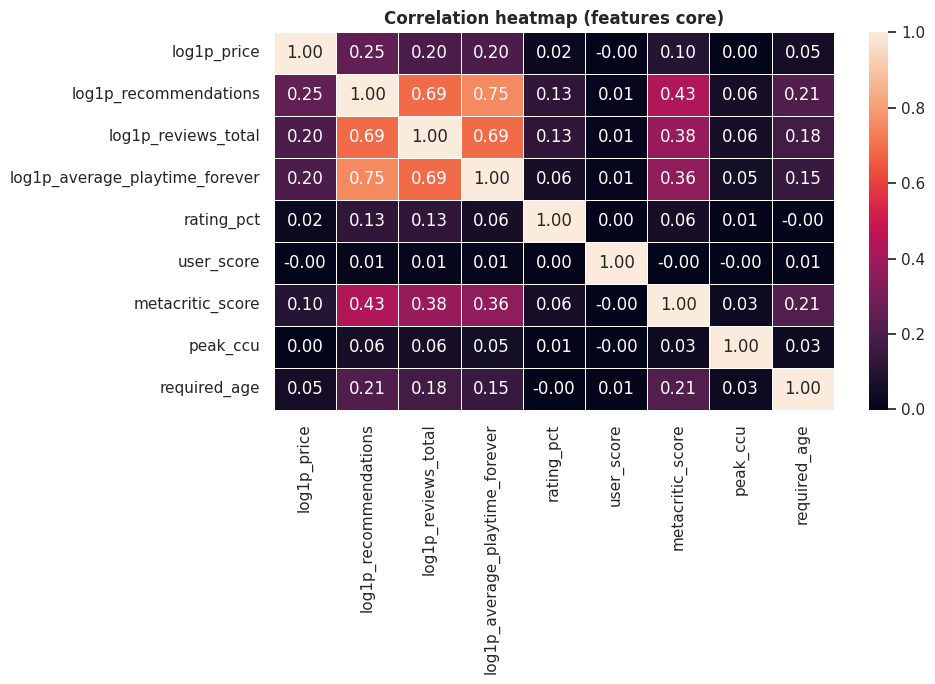

,log1p_price,log1p_recommendations,log1p_reviews_total,log1p_average_playtime_forever,rating_pct,user_score,metacritic_score,peak_ccu,required_age
log1p_price,1.000000,0.250541,0.201058,0.197823,0.022741,-0.002283,0.096888,0.001355,0.054994
log1p_recommendations,0.250541,1.000000,0.687388,0.754207,0.126199,0.009657,0.433761,0.057514,0.207908
log1p_reviews_total,0.201058,0.687388,1.000000,0.687768,0.126640,0.011465,0.379400,0.058698,0.176166
log1p_average_playtime_forever,0.197823,0.754207,0.687768,1.000000,0.057621,0.012833,0.360359,0.050560,0.148107
rating_pct,0.022741,0.126199,0.126640,0.057621,1.000000,0.004043,0.056756,0.005333,-0.001775
user_score,-0.002283,0.009657,0.011465,0.012833,0.004043,1.000000,-0.000336,-0.000252,0.008382
metacritic_score,0.096888,0.433761,0.379400,0.360359,0.056756,-0.000336,1.000000,0.032325,0.211002
peak_ccu,0.001355,0.057514,0.058698,0.050560,0.005333,-0.000252,0.032325,1.000000,0.030635
required_age,0.054994,0.207908,0.176166,0.148107,-0.001775,0.008382,0.211002,0.030635,1.000000


In [7]:
# PASO 4.1 - Correlaciones y relaciones numéricas (core)

# Selección de columnas numéricas clave (usa logs donde existan)
core_candidates = [
    "log1p_price",
    "log1p_recommendations",
    "log1p_reviews_total",
    "log1p_average_playtime_forever",
    "rating_pct",
    "user_score",
    "metacritic_score",
    "peak_ccu",
    "required_age",
]

core_cols = [c for c in core_candidates if c in df_eda.columns]

# Dataframe para correlación (solo numéricas)
corr_df = df_eda[core_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation heatmap (features core)", fontweight="bold")
plt.tight_layout()
plt.show()

display(corr)

## Interpretación
- Correlaciones altas pueden indicar **redundancia** (dos variables miden casi lo mismo).
- Correlaciones bajas no significan “inútil”, sino que aportan señal distinta (bueno para el modelo).
- En Steam es común que:
  - `log1p_recommendations` y `log1p_reviews_total` estén fuertemente relacionados,
  - `rating_pct` tenga una relación débil/moderada con popularidad,
  - `metacritic_score` y `user_score` se relacionen pero no perfectamente (crítica vs comunidad).

  

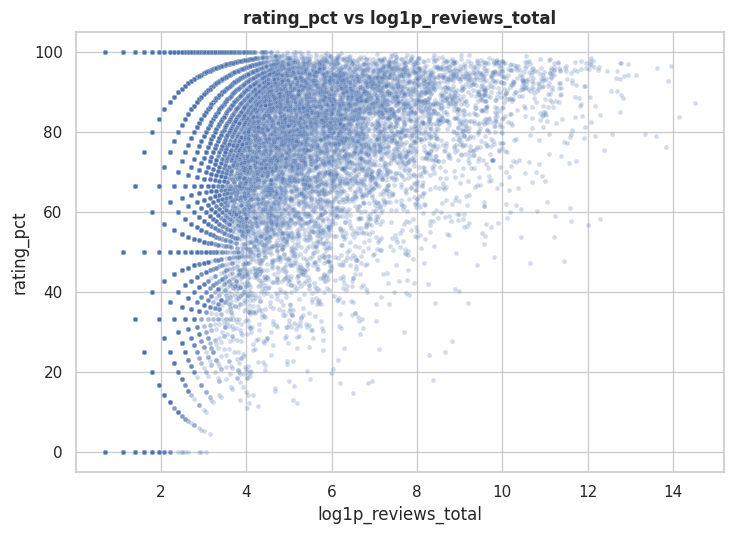

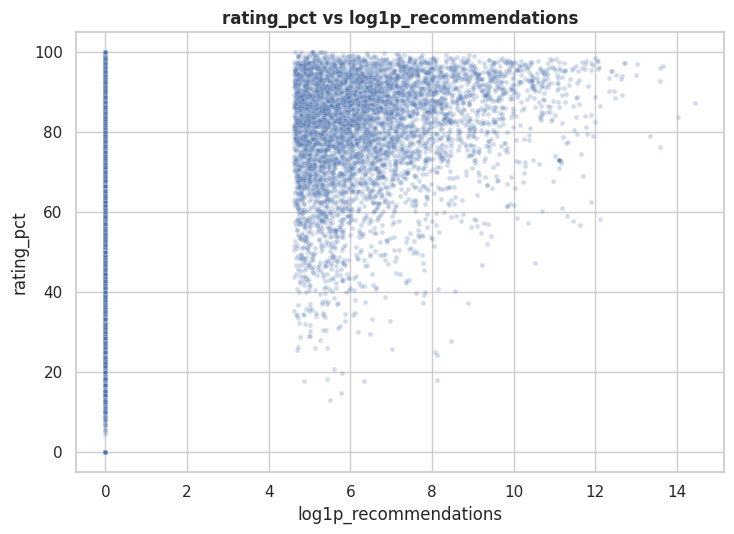

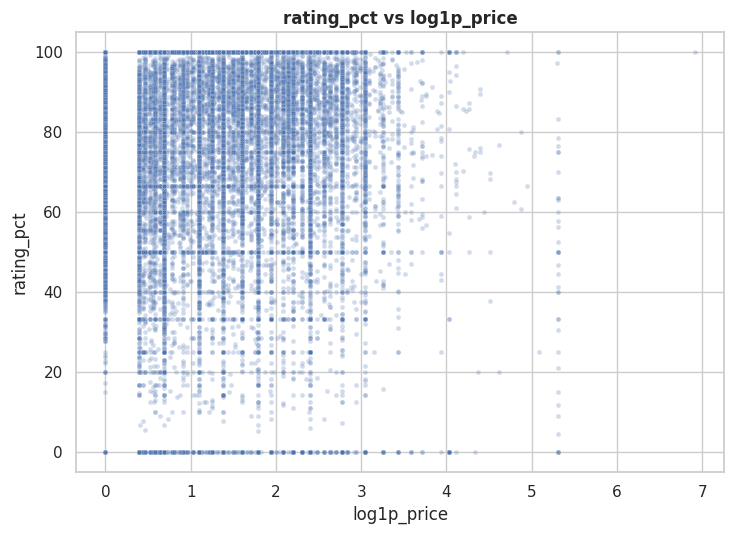

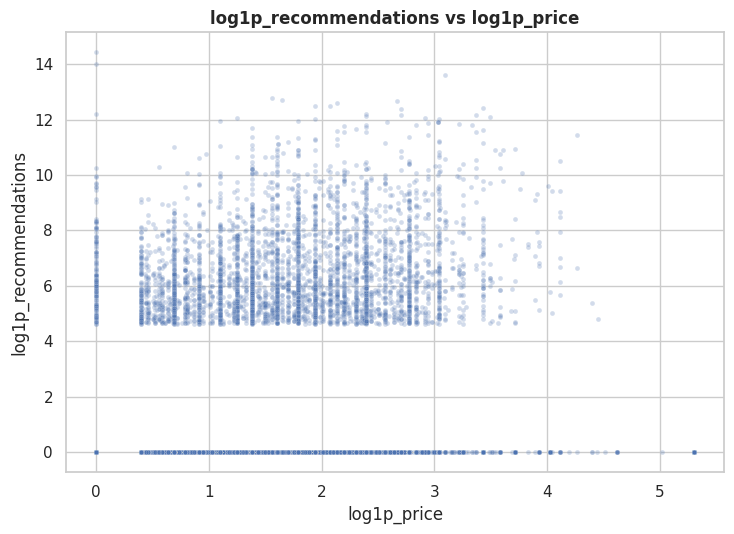

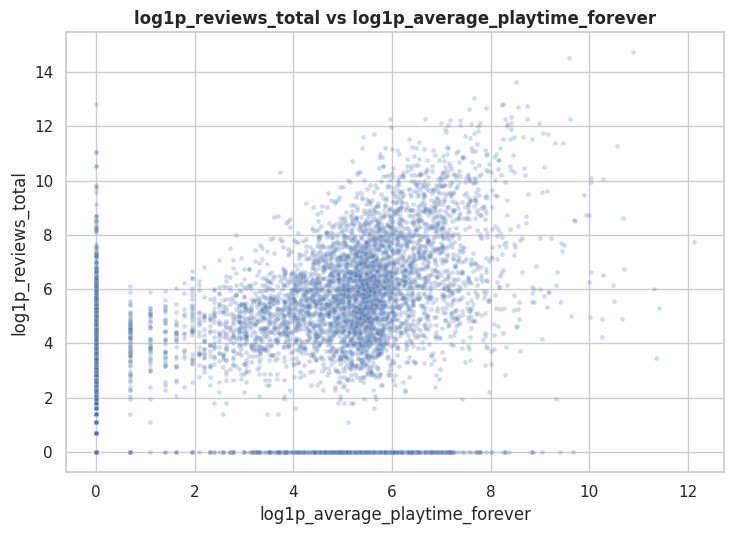

In [8]:
# PASO 4.2 - Relaciones clave (scatter)

def scatter(df, x, y, sample=25000, alpha=0.25):
    d = df[[x, y]].copy()
    d[x] = pd.to_numeric(d[x], errors="coerce")
    d[y] = pd.to_numeric(d[y], errors="coerce")
    d = d.dropna()
    if len(d) > sample:
        d = d.sample(sample, random_state=42)

    plt.figure(figsize=(7.5, 5.5))
    sns.scatterplot(data=d, x=x, y=y, alpha=alpha, s=12)
    plt.title(f"{y} vs {x}", fontweight="bold")
    plt.tight_layout()
    plt.show()

pairs = []

# Popularidad vs calidad
if "log1p_reviews_total" in df_eda.columns and "rating_pct" in df_eda.columns:
    pairs.append(("log1p_reviews_total", "rating_pct"))

if "log1p_recommendations" in df_eda.columns and "rating_pct" in df_eda.columns:
    pairs.append(("log1p_recommendations", "rating_pct"))

# Precio vs calidad/popularidad
if "log1p_price" in df_eda.columns and "rating_pct" in df_eda.columns:
    pairs.append(("log1p_price", "rating_pct"))

if "log1p_price" in df_eda.columns and "log1p_recommendations" in df_eda.columns:
    pairs.append(("log1p_price", "log1p_recommendations"))

# Engagement vs popularidad
if "log1p_average_playtime_forever" in df_eda.columns and "log1p_reviews_total" in df_eda.columns:
    pairs.append(("log1p_average_playtime_forever", "log1p_reviews_total"))

for x, y in pairs:
    scatter(df_eda, x, y)

## Conclusiones
- Si el scatter muestra “nube dispersa” → relación débil: ambas variables aportan señal diferente.
- Si se observa tendencia clara → relación moderada/fuerte: puede haber redundancia o una cadena causal plausible.
- Importante: en Steam no queremos que el recomendador se vuelva un “top popular”.
  - Si popularidad domina, luego aplicaremos estrategias de diversidad o reranking por calidad.

,pop_bucket,n,mean_rating,median_rating,mean_reviews,median_reviews
0,"(0.999, 5.0]",18446,72.303293,100.00,2.661661,2.0
1,"(5.0, 14.0]",14773,74.937994,81.82,9.471401,9.0
2,"(14.0, 41.0]",16793,75.678418,80.00,25.072828,24.0
3,"(41.0, 201.0]",16355,75.854480,79.07,94.354876,83.0
4,"(201.0, 8815087.0]",16582,80.665446,83.92,8848.089555,780.0


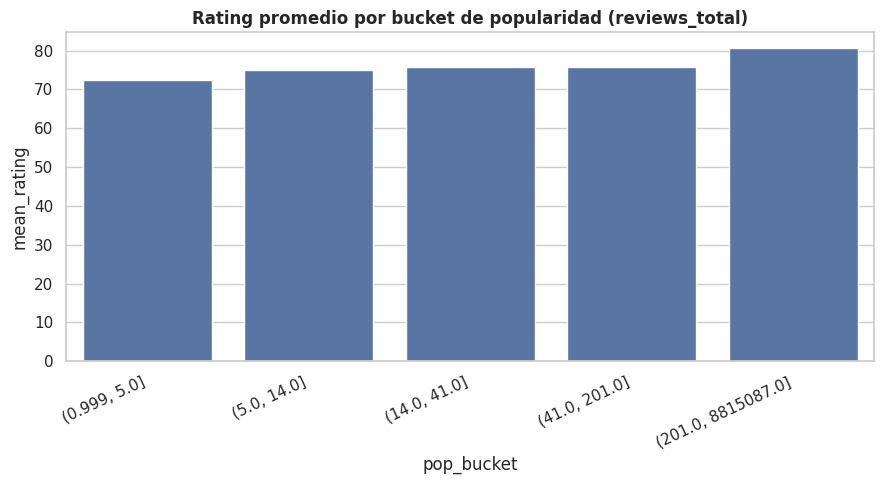

In [9]:
# PASO 4.3 - Popularidad en buckets vs calidad promedio

if "reviews_total" in df_eda.columns and "rating_pct" in df_eda.columns:
    tmp = df_eda[["reviews_total", "rating_pct"]].copy()
    tmp["reviews_total"] = pd.to_numeric(tmp["reviews_total"], errors="coerce")
    tmp["rating_pct"] = pd.to_numeric(tmp["rating_pct"], errors="coerce")
    tmp = tmp.dropna()

    # buckets por cuantiles de popularidad
    tmp["pop_bucket"] = pd.qcut(tmp["reviews_total"], q=5, duplicates="drop")

    summary = tmp.groupby("pop_bucket").agg(
        n=("rating_pct", "size"),
        mean_rating=("rating_pct", "mean"),
        median_rating=("rating_pct", "median"),
        mean_reviews=("reviews_total", "mean"),
        median_reviews=("reviews_total", "median"),
    ).reset_index()

    display(summary)

    plt.figure(figsize=(9,5))
    sns.barplot(data=summary, x="pop_bucket", y="mean_rating")
    plt.title("Rating promedio por bucket de popularidad (reviews_total)", fontweight="bold")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## Conclusiones
- Compara calidad promedio entre grupos de popularidad (de menos a más populares).
- Si el rating promedio sube con popularidad, significa que lo popular tiende a ser bien valorado.
- Si no sube (o baja), implica que popularidad ≠ calidad, y el sistema debería balancear ambas señales.
- Esto alimenta decisiones de diseño del recomendador: 
  - recomendar por similitud primero,
  - rerank por calidad cuando exista,
  - y evitar sesgos a “lo más popular” si queremos diversidad.

# 5 — Análisis multivariante con Géneros / Tags / Categorías

## Objetivo
Entender cómo se comportan las variables **list-like** (géneros, tags, categorías) en relación con:

- **Popularidad** (ej. `reviews_total`, `recommendations`)
- **Calidad percibida** (`rating_pct`)
- (Opcional) **Precio** y **engagement**

Este paso es crítico para un recomendador basado en contenido porque valida que:
- `genres` y `tags` tienen señal consistente (no solo ruido).
- Existen patrones interpretables (ej. “X tag suele tener mejores ratings”).
- Podemos usar estas variables para filtros y explicaciones (“te recomiendo esto porque…”).

## Consideración clave
Para evitar conclusiones engañosas:
- Solo analizaremos géneros/tags con **suficiente tamaño de muestra** (mínimo de juegos).
- Reportaremos resultados en dos ejes:
  - “Top por popularidad” (lo más consumido)
  - “Top por rating” (lo mejor valorado)

In [10]:
def list_to_pylist(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    return []

def group_metrics_from_listcol(df, list_col, min_n=200):
    # columnas que vamos a usar
    cols = [list_col]
    for c in ["rating_pct", "reviews_total", "recommendations", "price"]:
        if c in df.columns:
            cols.append(c)

    tmp = df[cols].copy()
    tmp[list_col] = tmp[list_col].apply(list_to_pylist)

    ex = tmp.explode(list_col)
    ex[list_col] = ex[list_col].astype(str).str.strip()
    ex = ex[(ex[list_col] != "") & (ex[list_col].str.lower() != "nan")]

    agg = {"n": (list_col, "size")}
    if "rating_pct" in ex.columns:
        agg["mean_rating"] = ("rating_pct", "mean")
        agg["median_rating"] = ("rating_pct", "median")
    if "reviews_total" in ex.columns:
        agg["median_reviews"] = ("reviews_total", "median")
        agg["mean_reviews"] = ("reviews_total", "mean")
    if "recommendations" in ex.columns:
        agg["median_recs"] = ("recommendations", "median")
    if "price" in ex.columns:
        agg["median_price"] = ("price", "median")

    g = ex.groupby(list_col).agg(**agg).reset_index()
    g = g[g["n"] >= min_n].sort_values("n", ascending=False)

    return g

,genres,n,mean_rating,median_rating,median_reviews,mean_reviews,median_recs,median_price
15,Indie,80630,76.503244,82.610,10.0,716.267332,0.0,2.49
6,Casual,50210,76.674587,83.330,6.0,395.541665,0.0,1.99
2,Action,46220,75.216889,80.950,11.0,2210.305193,0.0,2.99
3,Adventure,45141,75.638636,81.400,12.0,1332.479719,0.0,2.99
24,Simulation,24114,71.692356,76.920,12.0,1232.000207,0.0,2.99
27,Strategy,22400,74.220435,79.780,11.0,1122.614286,0.0,2.99
20,RPG,20972,74.533779,80.000,12.0,1849.838928,0.0,3.74
12,Free To Play,12172,75.875101,78.570,0.0,2705.374712,0.0,0.00
9,Early Access,11091,72.017491,77.780,5.0,702.554774,0.0,4.99
26,Sports,4882,71.635376,76.920,11.0,969.772429,0.0,2.99


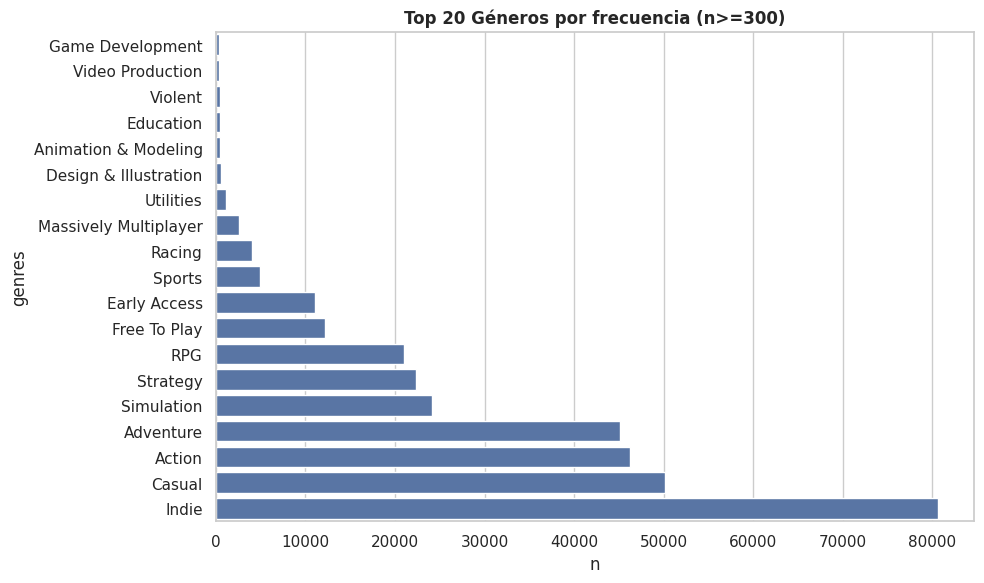

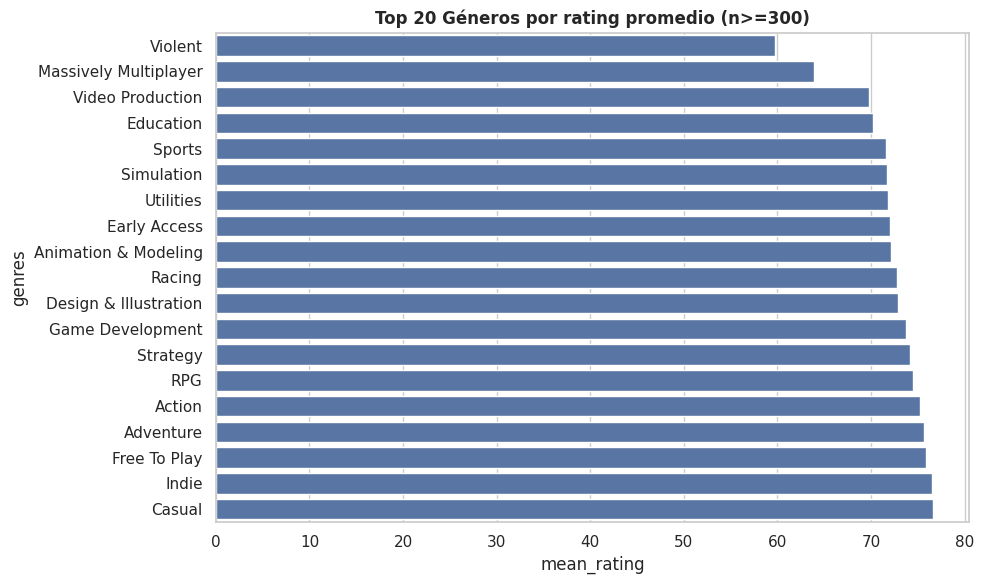

In [11]:
# Ajustamos min_n si quieres más/menos estricto
min_n_genres = 300

if "genres" in df_eda.columns:
    genres_stats = group_metrics_from_listcol(df_eda, "genres", min_n=min_n_genres)

    display(genres_stats.head(15))

    # Top 20 por frecuencia
    top_freq = genres_stats.head(20).sort_values("n")
    plt.figure(figsize=(10,6))
    sns.barplot(data=top_freq, x="n", y="genres")
    plt.title(f"Top 20 Géneros por frecuencia (n>={min_n_genres})", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Top 20 por rating (si existe)
    if "mean_rating" in genres_stats.columns:
        top_rating = genres_stats.sort_values("mean_rating", ascending=False).head(20).sort_values("mean_rating")
        plt.figure(figsize=(10,6))
        sns.barplot(data=top_rating, x="mean_rating", y="genres")
        plt.title(f"Top 20 Géneros por rating promedio (n>={min_n_genres})", fontweight="bold")
        plt.tight_layout()
        plt.show()

,tags,n,mean_rating,median_rating,median_reviews,mean_reviews,median_recs,median_price
352,singleplayer,50350,78.342067,84.680,22.0,2071.929096,0.0,2.99
201,indie,48552,75.721940,81.630,24.0,1038.546033,0.0,2.49
16,action,36809,75.238473,80.950,23.0,3153.731261,0.0,2.99
69,casual,36564,76.681941,83.330,18.0,806.625014,0.0,2.09
22,adventure,35196,75.589176,81.250,28.0,2162.029208,0.0,2.99
3,2d,26792,81.753409,88.640,19.0,910.122723,0.0,2.50
7,3d,17996,74.830288,81.495,15.0,946.112525,0.0,2.99
351,simulation,17893,71.855090,76.920,35.0,2388.309283,0.0,3.19
378,strategy,17848,74.385061,80.000,28.0,2702.378418,0.0,2.99
307,puzzle,16368,80.316949,86.670,23.0,834.283663,0.0,2.49


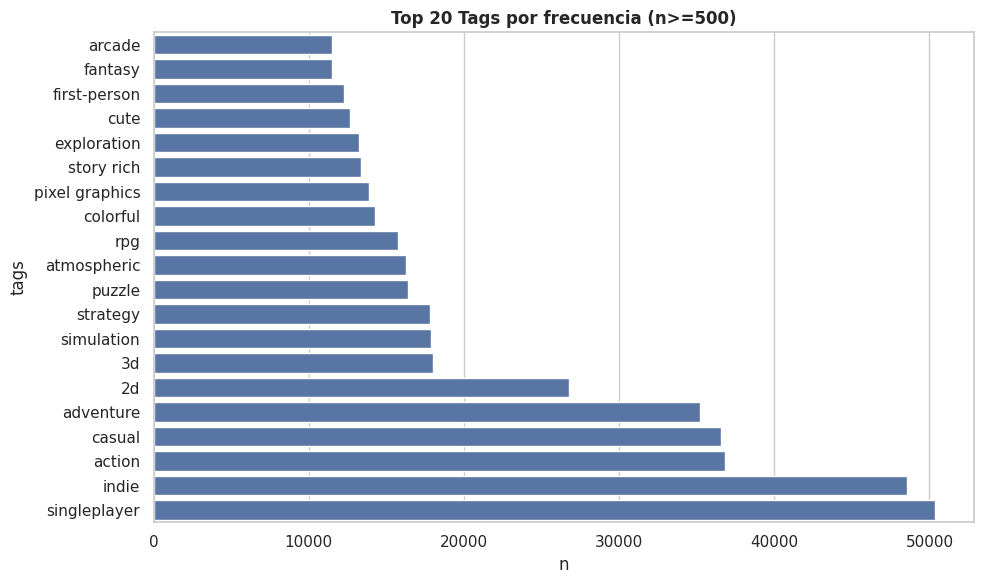

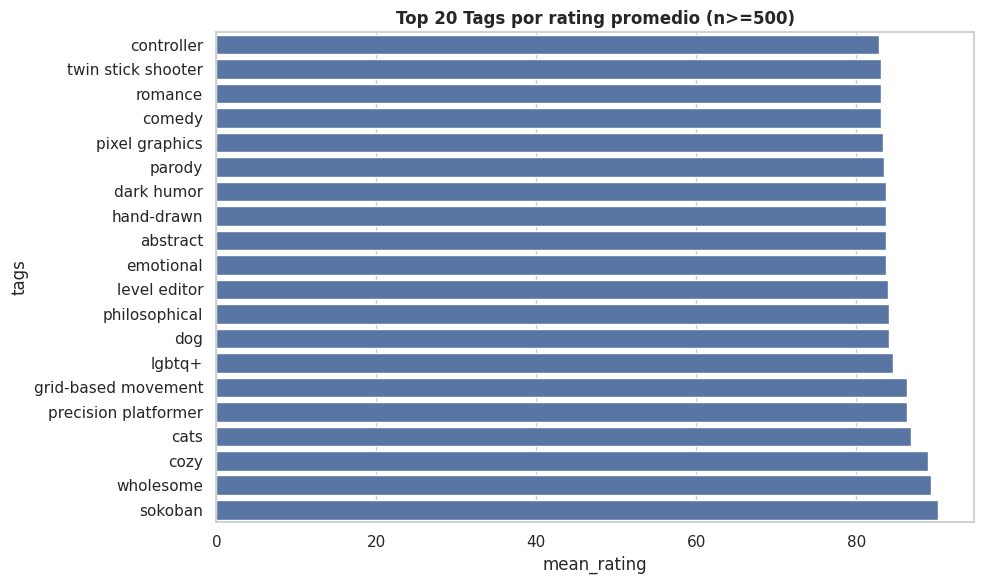

In [12]:
min_n_tags = 500  # tags son más ruidosos; subimos el umbral

if "tags" in df_eda.columns:
    tags_stats = group_metrics_from_listcol(df_eda, "tags", min_n=min_n_tags)

    display(tags_stats.head(15))

    # Top 20 por frecuencia
    top_freq = tags_stats.head(20).sort_values("n")
    plt.figure(figsize=(10,6))
    sns.barplot(data=top_freq, x="n", y="tags")
    plt.title(f"Top 20 Tags por frecuencia (n>={min_n_tags})", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Top 20 por rating (si existe)
    if "mean_rating" in tags_stats.columns:
        top_rating = tags_stats.sort_values("mean_rating", ascending=False).head(20).sort_values("mean_rating")
        plt.figure(figsize=(10,6))
        sns.barplot(data=top_rating, x="mean_rating", y="tags")
        plt.title(f"Top 20 Tags por rating promedio (n>={min_n_tags})", fontweight="bold")
        plt.tight_layout()
        plt.show()

## Conclusiones
- **Top por frecuencia** refleja el catálogo “dominante” (lo que más se publica/consume).
- **Top por rating** refleja qué tipos de experiencias tienden a gustar más (cuando hay reseñas).
- Si un género/tag tiene:
  - alta frecuencia + buen rating → excelente señal para recomendaciones y “default picks”.
  - baja frecuencia + buen rating → bueno para diversidad (joyas escondidas).
  - alta frecuencia + rating medio/bajo → útil para entender sesgos del mercado (no todo lo popular es top).

Estas conclusiones alimentan directamente:
- filtros del usuario (por género/tag),
- explicación de recomendaciones (interpretabilidad),
- y estrategias de diversidad (evitar que todo sea “Action” o “Indie”).

# 6 — Co-ocurrencia de Tags y Géneros (relaciones entre etiquetas)

## Objetivo
Entender qué **tags** y **géneros** tienden a aparecer juntos en el catálogo.

Esto es útil porque:
- revela “familias” de juegos (ej. *pixel graphics* suele convivir con *2d* y *indie*),
- ayuda a explicar recomendaciones (transparencia),
- y sugiere señales para mejorar el modelo (por ejemplo, enriquecer el perfil de un juego con tags altamente asociados).

## Qué vamos a producir
- Un ranking de **pares más comunes** (ej. Tag A + Tag B).
- Un gráfico de barras con los pares top.
- (Opcional) una mirada a asociaciones condicionadas por un tag “semilla” (ej. “cuando aparece *story rich*, ¿qué más suele aparecer?”).

In [13]:
from itertools import combinations
from collections import Counter

# --- Config ---
LIST_COL = "tags"          # puedes cambiar a "genres" si quieres
TOP_TAGS = 250             # limita el universo para evitar ruido
SAMPLE_ROWS = 40000        # muestra para velocidad (ajusta si quieres)
TOP_PAIRS = 25             # pares a mostrar

# --- Validación ---
if LIST_COL not in df_eda.columns:
    raise ValueError(f"No existe la columna {LIST_COL} en df_eda")

# 1) Universo de tags más frecuentes (para reducir combinatoria)
# Reutiliza tags_stats si existe; si no, lo calculamos
if "tags_stats" in globals():
    vocab = tags_stats.sort_values("n", ascending=False).head(TOP_TAGS)["tags"].astype(str).tolist()
else:
    # cálculo rápido de vocabulario
    s = df_eda[LIST_COL].dropna().head(60000).apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
    ex = pd.Series(s).explode().dropna().astype(str).str.strip()
    ex = ex[(ex != "") & (ex.str.lower() != "nan")]
    vocab = ex.value_counts().head(TOP_TAGS).index.tolist()

vocab_set = set(vocab)
print("Vocab size:", len(vocab_set))

# 2) Sample de filas (para velocidad)
df_s = df_eda[[LIST_COL]].dropna()
if len(df_s) > SAMPLE_ROWS:
    df_s = df_s.sample(SAMPLE_ROWS, random_state=42)

# 3) Conteo de pares (combinaciones dentro de cada juego)
pair_counts = Counter()

for tags in df_s[LIST_COL]:
    tags = tags.tolist() if isinstance(tags, np.ndarray) else tags
    tags = [str(t).strip() for t in tags if str(t).strip() and str(t).lower() != "nan"]
    tags = [t for t in tags if t in vocab_set]
    tags = sorted(set(tags))
    if len(tags) < 2:
        continue
    for a, b in combinations(tags, 2):
        pair_counts[(a, b)] += 1

pairs_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.most_common(TOP_PAIRS)],
    columns=["tag_a", "tag_b", "count"]
)

display(pairs_df)

Vocab size: 250


,tag_a,tag_b,count
0,indie,singleplayer,10139
1,casual,indie,7672
2,casual,singleplayer,7524
3,adventure,singleplayer,7315
4,action,indie,7243
5,action,singleplayer,7025
6,adventure,indie,6910
7,2d,singleplayer,6863
8,action,adventure,5390
9,2d,indie,5203


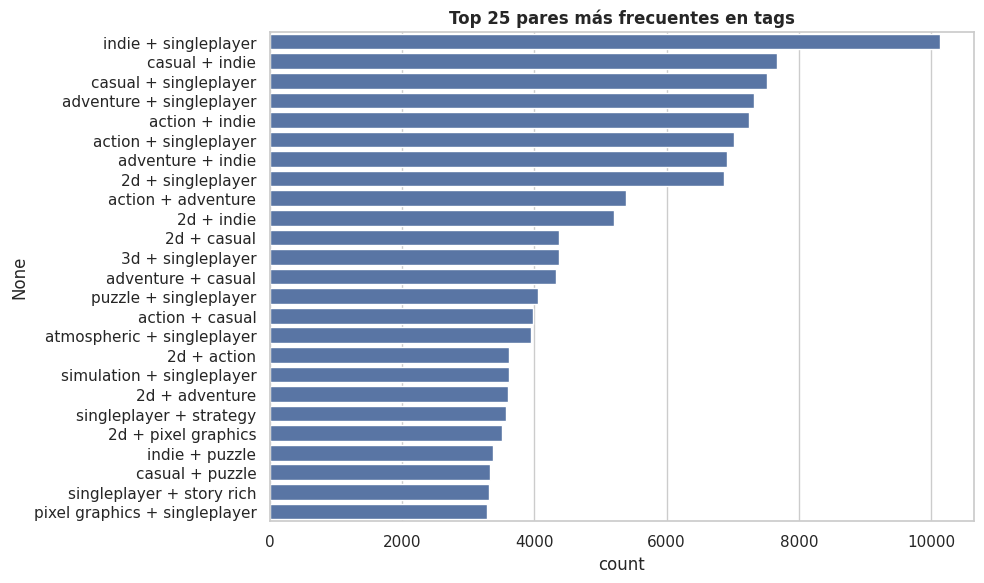

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=pairs_df.sort_values("count"),
    x="count",
    y=pairs_df["tag_a"] + " + " + pairs_df["tag_b"]
)
plt.title(f"Top {len(pairs_df)} pares más frecuentes en {LIST_COL}", fontweight="bold")
plt.tight_layout()
plt.show()

,tag,count
0,2d,3508
1,singleplayer,3289
2,indie,2727
3,action,2410
4,adventure,2022
5,retro,1720
6,casual,1700
7,rpg,1176
8,platformer,1078
9,arcade,1076


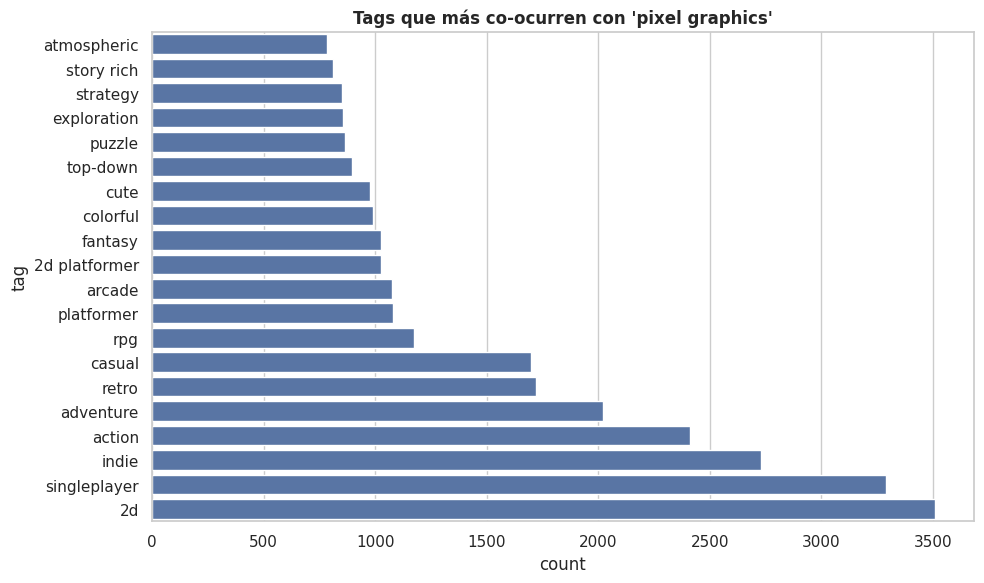

In [15]:
SEED_TAG = "pixel graphics"   # cámbialo por el que quieras (ej: "pixel graphics", "singleplayer")

df_s2 = df_eda[[LIST_COL]].dropna()
if len(df_s2) > SAMPLE_ROWS:
    df_s2 = df_s2.sample(SAMPLE_ROWS, random_state=42)

co = Counter()

for tags in df_s2[LIST_COL]:
    tags = tags.tolist() if isinstance(tags, np.ndarray) else tags
    tags = [str(t).strip() for t in tags if str(t).strip() and str(t).lower() != "nan"]
    tags = set(tags)
    if SEED_TAG in tags:
        for t in tags:
            if t != SEED_TAG:
                co[t] += 1

seed_df = pd.DataFrame(co.most_common(20), columns=["tag", "count"])
display(seed_df)

plt.figure(figsize=(10,6))
sns.barplot(data=seed_df.sort_values("count"), x="count", y="tag")
plt.title(f"Tags que más co-ocurren con '{SEED_TAG}'", fontweight="bold")
plt.tight_layout()
plt.show()

## Interpretacion
- Los pares más frecuentes representan “combinaciones típicas” de etiquetas en Steam.
- Esto ayuda a:
  - entender perfiles comunes (ej. *2d + pixel graphics + indie*),
  - explicar recomendaciones (“se parece porque comparte estos tags”),
  - y diseñar diversidad (si siempre aparecen juntos, puedes sugerir variantes).

## Conclusiones
- Identificamos las combinaciones más comunes de tags y observamos clústeres naturales.
- Ciertas etiquetas funcionan como “núcleo” (ej. singleplayer/indie) y arrastran otras descripciones de estilo.
- Estas relaciones justifican usar tags como señal complementaria al texto para fortalecer similitud semántica.

# 7 — Feature Engineering orientado al Recomendador

## Objetivo
Preparar un conjunto de features que sirvan directamente para el sistema de recomendación.

En un recomendador basado en contenido (NLP/embeddings) necesitamos:
1) Un **texto representativo** del juego (perfil semántico).
2) Metadatos interpretables para:
   - enriquecer el texto (tags/géneros/categorías),
   - y habilitar filtros del usuario (precio, OS, idioma, edad).

## Qué vamos a construir
- `text_profile`: un único campo de texto por juego que resume su “identidad”.
- `free_to_play`: indicador simple para diferenciar juegos gratuitos.

## Relevancia
Un campo consolidado evita depender solo de una descripción larga (que puede estar vacía o ser ruidosa).
Además, incorporar tags/géneros al texto mejora la similitud semántica y aumenta la interpretabilidad:
"se recomienda porque comparte estos elementos".

In [16]:
# PASO 7.1 - Selección de columna de texto base

text_candidates = ["text_description", "detailed_description", "short_description"]
text_candidates = [c for c in text_candidates if c in df_eda.columns]

print("Text candidates:", text_candidates)

for c in text_candidates:
    coverage = df_eda[c].fillna("").astype(str).str.len().gt(0).mean()
    avg_len = df_eda[c].fillna("").astype(str).str.len().mean()
    print(f"{c} -> coverage: {coverage:.3f} | avg_len: {avg_len:.1f}")

Text candidates: ['text_description', 'detailed_description', 'short_description']
text_description -> coverage: 0.932 | avg_len: 1229.7
detailed_description -> coverage: 0.931 | avg_len: 1229.5
short_description -> coverage: 0.932 | avg_len: 184.5


## 7.2 — Construcción de `text_profile`

En datasets grandes, crear un texto por fila puede ser costoso.  
Para evitar caídas del kernel, construimos el perfil de forma eficiente:

- Limitamos la longitud del texto base (para no inflar memoria).
- Limitamos la cantidad de tags/géneros/categorías incluidos.
- Procesamos el dataset por **bloques** (chunks), reduciendo el consumo de RAM.

El resultado es el mismo: un campo `text_profile` usable para embeddings y explicabilidad.

In [17]:


# Base de texto (misma lógica)
base_text = "text_description" if "text_description" in df_eda.columns else (
    "detailed_description" if "detailed_description" in df_eda.columns else (
        "short_description" if "short_description" in df_eda.columns else None
    )
)
print("Base text selected:", base_text)

# Parámetros para controlar tamaño
MAX_TEXT_CHARS = 900     # recorte del texto base para evitar strings gigantes
MAX_TAGS = 12
MAX_GENRES = 5
MAX_CATS = 8

def to_list(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    return []

# Limpieza ligera (evita regex pesado por fila)
def clean_light(s):
    s = "" if pd.isna(s) else str(s)
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    # quitar HTML simple sin regex pesado
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def join_top(items, max_n):
    items = [str(i).strip() for i in items if str(i).strip() and str(i).lower() != "nan"]
    # unique manteniendo orden
    seen = set()
    out = []
    for it in items:
        if it not in seen:
            out.append(it)
            seen.add(it)
        if len(out) >= max_n:
            break
    return ", ".join(out)

def build_profile_row(row):
    name = clean_light(row["name"]) if "name" in df_eda.columns else ""
    text = clean_light(row[base_text]) if base_text else ""
    if len(text) > MAX_TEXT_CHARS:
        text = text[:MAX_TEXT_CHARS].rstrip() + "..."

    genres = join_top(to_list(row["genres"]), MAX_GENRES) if "genres" in df_eda.columns else ""
    tags   = join_top(to_list(row["tags"]), MAX_TAGS) if "tags" in df_eda.columns else ""
    cats   = join_top(to_list(row["categories"]), MAX_CATS) if "categories" in df_eda.columns else ""

    parts = []
    if name:   parts.append(f"Title: {name}.")
    if genres: parts.append(f"Genres: {genres}.")
    if cats:   parts.append(f"Categories: {cats}.")
    if tags:   parts.append(f"Tags: {tags}.")
    if text:   parts.append(text)

    return " ".join(parts).strip()

# --- Construcción por chunks ---
df_eda["text_profile"] = ""  # pre-allocate
idx = df_eda.index.to_numpy()

CHUNK = 12000  # ajusta si quieres (8k–20k suele ir bien)
for start in range(0, len(idx), CHUNK):
    end = min(start + CHUNK, len(idx))
    chunk_idx = idx[start:end]
    df_eda.loc[chunk_idx, "text_profile"] = df_eda.loc[chunk_idx].apply(build_profile_row, axis=1)
    print(f"Built text_profile: {end}/{len(idx)}")

# sanity
display(df_eda[["name", "text_profile"]].sample(5, random_state=42))
print("Coverage text_profile:", df_eda["text_profile"].fillna("").str.len().gt(0).mean().round(4))
print("Avg length text_profile:", df_eda["text_profile"].fillna("").str.len().mean().round(1))

Base text selected: text_description


Built text_profile: 12000/122611
Built text_profile: 24000/122611
Built text_profile: 36000/122611
Built text_profile: 48000/122611
Built text_profile: 60000/122611
Built text_profile: 72000/122611
Built text_profile: 84000/122611
Built text_profile: 96000/122611
Built text_profile: 108000/122611
Built text_profile: 120000/122611
Built text_profile: 122611/122611


,name,text_profile
33398,Gold Hunter Playtest,Title: Gold Hunter Playtest.
24368,BLÖCK,"Title: BLÖCK. Genres: Casual, Indie. Categorie..."
99907,Mind Space,Title: Mind Space. Genres: Action. Categories:...
48012,Where The Stars Brought Us,Title: Where The Stars Brought Us. Genres: Cas...
109018,Project Temporality,"Title: Project Temporality. Genres: Action, Ad..."


Coverage text_profile: 1.0
Avg length text_profile: 939.7


# 7.3 — Persistencia del dataset EDA y checklist de features

## Objetivo
Evitar recomputar `text_profile` (costoso) cada vez que abrimos el notebook y dejar un “dataset de trabajo” listo para el recomendador.

Además, validamos que ya tenemos:
- **Feature principal de contenido:** `text_profile`
- **Señales auxiliares:** popularidad, engagement, calidad
- **Campos de filtrado:** precio, OS, edad, idiomas

## Relevancia
Esto separa claramente:
- “EDA / preparación de datos” (este notebook)
- de “entrenamiento / recomendación” (notebook/modelo siguiente)

Y hace el proyecto reproducible: cualquiera puede cargar `df_eda.parquet` y seguir.

In [18]:
from pathlib import Path

# Guardar versión EDA (con text_profile ya construido)
out_path = PROCESSED_DIR / "df_eda.parquet"
df_eda.to_parquet(out_path, index=False)
print("Saved:", out_path)

# Checklist de columnas clave
needed_for_model = ["app_id", "name", "text_profile"]
signals = ["reviews_total", "recommendations", "rating_pct", "user_score", "metacritic_score", "average_playtime_forever", "peak_ccu"]
filters = ["price", "free_to_play", "windows", "mac", "linux", "required_age", "supported_languages"]

present_model = [c for c in needed_for_model if c in df_eda.columns]
present_signals = [c for c in signals if c in df_eda.columns]
present_filters = [c for c in filters if c in df_eda.columns]

print("\nModel-ready:", present_model)
print("Signals:", present_signals)
print("Filters:", present_filters)

# quick sanity: ejemplos
display(df_eda[present_model].sample(5, random_state=42))

Saved: /workspaces/Final-Project-Videogame-Recommender/data/processed/df_eda.parquet

Model-ready: ['app_id', 'name', 'text_profile']
Signals: ['reviews_total', 'recommendations', 'rating_pct', 'user_score', 'metacritic_score', 'average_playtime_forever', 'peak_ccu']
Filters: ['price', 'windows', 'mac', 'linux', 'required_age', 'supported_languages']


,app_id,name,text_profile
33398,1472640,Gold Hunter Playtest,Title: Gold Hunter Playtest.
24368,2133540,BLÖCK,"Title: BLÖCK. Genres: Casual, Indie. Categorie..."
99907,1702350,Mind Space,Title: Mind Space. Genres: Action. Categories:...
48012,1968400,Where The Stars Brought Us,Title: Where The Stars Brought Us. Genres: Cas...
109018,290320,Project Temporality,"Title: Project Temporality. Genres: Action, Ad..."


# 8 — Conclusiones del EDA e implicaciones para el recomendador

## Hallazgos clave del dataset
- El dataset contiene ~122k juegos y presenta patrones típicos de catálogos de Steam:
  - **colas largas** en popularidad y engagement,
  - **señales de rating incompletas**,
  - metadatos ricos (géneros/tags/categorías) útiles para recomendación por contenido.

## Implicaciones para el modelo
1) **Recomendación basada en contenido (texto + tags + géneros)** es viable  
   porque `text_profile` tiene cobertura total y encapsula la “identidad” del juego.

2) Las señales de **popularidad** (reviews/recommendations/playtime) están correlacionadas  
   y pueden usarse para reranking, pero con cuidado para no sesgar todo a “lo más popular”.

3) `rating_pct` tiene missing relevante (~32%) y correlación débil con popularidad  
   por lo que se usará como mejora opcional, no como requisito.

4) Co-ocurrencias de tags muestran clústeres naturales (ej. pixel graphics ↔ 2d ↔ indie ↔ retro)  
   lo que apoya explicabilidad y consistencia semántica.

## Limitaciones
- Ratings incompletos: no todos los juegos tienen señal de reseñas suficiente.
- Outliers fuertes (ej. precios extremos): requieren escalas `log1p` para análisis y features numéricas.
- Tags muy variados: se controlan con mínimos de muestra para evitar ruido.

In [19]:
insights = []

def add_insight(title, value):
    insights.append({"insight": title, "value": value})

add_insight("Total juegos", f"{len(df_eda):,}")
add_insight("Columnas", df_eda.shape[1])

if "price" in df_eda.columns:
    p = pd.to_numeric(df_eda["price"], errors="coerce")
    add_insight("Precio mediana", f"{p.median():.2f}")
    add_insight("Precio P75", f"{p.quantile(0.75):.2f}")
    add_insight("Precio max", f"{p.max():.2f}")
    add_insight("Free-to-play (%)", f"{(p.fillna(0)==0).mean()*100:.1f}%")

if "rating_pct" in df_eda.columns:
    r = pd.to_numeric(df_eda["rating_pct"], errors="coerce")
    add_insight("Rating disponible (%)", f"{r.notna().mean()*100:.1f}%")
    add_insight("Rating mediana (cuando existe)", f"{r.dropna().median():.2f}")

if "text_profile" in df_eda.columns:
    tl = df_eda["text_profile"].fillna("").str.len()
    add_insight("Text_profile coverage (%)", f"{(tl>0).mean()*100:.1f}%")
    add_insight("Text_profile avg length", f"{tl.mean():.1f} chars")

insights_df = pd.DataFrame(insights)
display(insights_df)

,insight,value
0,Total juegos,"122,611"
1,Columnas,48
2,Precio mediana,2.24
3,Precio P75,5.24
4,Precio max,999.98
5,Free-to-play (%),21.4%
6,Rating disponible (%),67.7%
7,Rating mediana (cuando existe),81.82
8,Text_profile coverage (%),100.0%
9,Text_profile avg length,939.7 chars


# PASO 8 — Conclusiones del EDA e implicaciones para el recomendador

## Resumen del dataset
Trabajamos con un catálogo de **122,611 videojuegos**. Tras la limpieza y preparación, el dataset final para análisis y modelado incluye **48 columnas**, combinando:

- **Texto (contenido):** descripciones + metadatos enriquecidos.
- **Metadatos estructurados:** géneros, tags, categorías, idiomas, plataformas.
- **Señales cuantitativas:** popularidad, engagement y métricas de calidad.

Este mix permite construir un recomendador realista: primero por similitud de contenido y luego refinado por señales de calidad/popularidad cuando estén disponibles.

---

## Hallazgos clave (lo que nos dice el dataset)

### 1) El mercado tiene “colas largas” (pocos juegos concentran casi todo)
Variables como popularidad y tiempo de juego tienden a concentrarse en pocos títulos, mientras la mayoría tiene valores bajos.  
Esto no es un problema: es un comportamiento natural del catálogo de Steam.

**Implicación:** para visualizar y comparar correctamente usamos transformaciones `log1p` en variables de conteo (ej. recomendaciones, reseñas, playtime). Esto evita que unos pocos outliers aplasten el análisis y mejora la estabilidad si estas señales se usan como features.

---

### 2) Precio: la mayoría de juegos son baratos, con outliers extremos
- **Mediana del precio:** **$2.24**
- **75% cuesta ≤ $5.24**
- **Máximo observado:** **$999.98** (outlier fuerte)
- **Free-to-play:** **21.4%** del catálogo

**Implicación para el recomendador:**
- `price` se usa como **filtro** (presupuesto).
- `log1p_price` se usa para análisis y para evitar distorsión por outliers cuando el precio se combine con otras señales.

---

### 3) La señal de rating existe, pero no para todos
- **Rating disponible:** **67.7%**
- **Mediana del rating (cuando existe):** **81.82**

**Implicación:** el recomendador no puede depender del rating para funcionar.  
En lugar de eso, el rating se usa como **mejora opcional**:
- *Reranking:* si varios juegos son similares en contenido, priorizar los mejor valorados.
- *Calidad asistida:* elevar recomendaciones “seguras” cuando hay señal.

---

### 4) Popularidad ≠ calidad (y esto afecta el diseño)
El análisis multivariante mostró que las métricas de popularidad/engagement están relacionadas entre sí, pero tienen relación débil con el rating.  
En la práctica:
- hay juegos muy populares con rating “normal”
- y juegos con excelente rating que no son masivos (joyas ocultas)

**Implicación:** el recomendador debe balancear:
- relevancia semántica (contenido)
- calidad (si existe)
- y diversidad (evitar que todo sea “lo más popular”)

---

### 5) Tags y géneros forman “familias” consistentes (co-ocurrencia)
La co-ocurrencia de tags revela combinaciones frecuentes y clústeres naturales.  
Ejemplo claro observado:
- *pixel graphics* aparece fuertemente asociado a *2d*, *indie*, *retro*, entre otros.

**Implicación:** esto refuerza que tags/géneros no son solo “decoración”, sino estructura semántica útil para:
- explicabilidad (“se recomienda porque comparte X e Y”)
- enriquecimiento del perfil del juego
- mejorar similitud del modelo (más contexto por título)

---

## Qué queda listo para el modelo (salida del EDA)

### Campo principal de contenido (para embeddings)
Construimos `text_profile`, un texto consolidado por juego que incluye:
- nombre del juego
- géneros, categorías, tags (limitados para evitar ruido)
- descripción base (`text_description`)

Resultados:
- **Cobertura:** **100%**
- **Longitud promedio:** **~940 caracteres**

**Implicación:** es una base sólida para un recomendador semántico con embeddings.

### Señales auxiliares para reranking (cuando existan)
- `reviews_total`, `recommendations` (popularidad)
- `average_playtime_forever`, `peak_ccu` (engagement)
- `rating_pct`, `user_score`, `metacritic_score` (calidad)

### Filtros para la app
- `price`
- `windows / mac / linux`
- `required_age`
- `supported_languages`

---

## Limitaciones y cómo las manejamos
- **Ratings incompletos:** se usan como señal opcional, no como dependencia.
- **Outliers (precio, popularidad):** se controlan con `log1p` y recortes visuales por percentiles.
- **Tags muy variados:** se analizan con mínimos de muestra para evitar conclusiones basadas en pocos juegos.

---

## Conclusión final
El dataset es adecuado para un recomendador de Steam basado en contenido:
- `text_profile` permite similitud semántica consistente (cobertura total).
- tags/géneros añaden señal y explicabilidad.
- señales numéricas permiten mejorar ranking y personalización sin sesgar el sistema solo a popularidad.

El siguiente paso natural es entrenar/usar embeddings sobre `text_profile` y combinarlo con filtros y reranking usando las señales disponibles.